In [16]:
import pandas as pd
import matplotlib.pyplot as plt

### 資料前處理

In [17]:
df_train=pd.read_csv('train_data_dnn_v2.csv',index_col=0)
df_test=pd.read_csv('test_day3_dnn_v2.csv',index_col=0)
result_test_bid_id=df_test['bid_id'].copy()
df_train[df_train.select_dtypes(include='int64').columns] = df_train.select_dtypes(include='int64').astype('int32')
df_test[df_test.select_dtypes(include='int64').columns] = df_test.select_dtypes(include='int64').astype('int32')

In [19]:
from sklearn.preprocessing import LabelEncoder

def label_encode_columns(train_df, test_df, cols):
    encoders = {}
    
    for col in cols:
        le = LabelEncoder()
        # 只用 train 資料 fit，避免資料洩漏
        le.fit(train_df[col].astype(str))
        
        # 使用 try/catch 保證未知類別轉成 -1
        def safe_transform(series):
            classes = set(le.classes_)
            return series.astype(str).apply(lambda x: le.transform([x])[0] if x in classes else -1)

        train_df[col + "_le"] = safe_transform(train_df[col])
        test_df[col + "_le"] = safe_transform(test_df[col])
        
        encoders[col] = le

    return train_df, test_df, encoders
col=['browser_version','day']
df_train, df_test, encoders = label_encode_columns(df_train, df_test, col)

In [24]:
df_train=df_train.drop(columns=['browser_version','day'])
df_test=df_test.drop(columns=['browser_version','day'])

In [26]:
#df_test=df_test.drop(columns=['bid_id'])
print(f'train shape:{df_train.shape}')
print(f'test shape:{df_test.shape}')


train shape:(1760309, 26)
test shape:(446650, 25)


In [27]:
from sklearn.model_selection import train_test_split
y=df_train['click'].astype(int)
X=df_train.drop(columns=['click'])
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
X_test = df_test[X_train.columns]

### 建立模型

In [28]:
import torch
from sklearn.preprocessing import StandardScaler

# 類別特徵（embedding 的 index）
cat_embed_cols = [
    'ip_part1_le', 'domain_top25_le', 'adslotid_top30_le',
    'user_tag_1_le', 'user_tag_2_le', 'user_tag_3_le', 'user_tag_4_le',
    'user_tag_5_le', 'user_tag_6_le', 'user_tag_7_le', 'ad_exchange_le',
    'ad_slot_visibility_le', 'creative_id_le', 'browser_le', 'os_le',
    'city_top50_le', 'region_top30_le','browser_version_le','day_le','hour'
]

# 數值特徵（已經標準化）
num_cols = [
    'ad_slot_width', 'ad_slot_height', 'ad_slot_floor_price',
    'is_mobile', 'is_old_browser'
]

# 標準化數值特徵
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [35]:
import torch.nn as nn
import torch.nn.functional as F

class DNNWithEmbeddings(nn.Module):
    def __init__(self, embedding_info, num_numerical, hidden_dims=[256, 128]):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_categories + 1, emb_dim)  # +1 for unknown
            for num_categories, emb_dim in embedding_info
        ])
        
        emb_total_dim = sum([emb_dim for _, emb_dim in embedding_info])
        input_dim = emb_total_dim + num_numerical
        
        layers = []
        for h in hidden_dims:
            layers.append(nn.Linear(input_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            input_dim = h
        layers.append(nn.Linear(input_dim, 1))  # 二分類輸出
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_cat, x_num):
        embedded = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embedded + [x_num], dim=1)
        return self.mlp(x)  # 0~1 機率輸出


In [36]:
embedding_info = []
for col in cat_embed_cols:
    num_classes = X_train[col].nunique()
    emb_dim = min(50, (num_classes + 1) // 2)  # 可自定規則
    embedding_info.append((num_classes, emb_dim))

In [37]:
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix

Epoch 1 | Loss: 1.3845 | Train AUC: 0.6816 | Val AUC: 0.5053 | Val TPR: 1.0000
Epoch 2 | Loss: 1.3590 | Train AUC: 0.7261 | Val AUC: 0.5254 | Val TPR: 1.0000
Epoch 3 | Loss: 1.3339 | Train AUC: 0.7448 | Val AUC: 0.5630 | Val TPR: 1.0000
Epoch 4 | Loss: 1.3072 | Train AUC: 0.7570 | Val AUC: 0.5752 | Val TPR: 1.0000
Epoch 5 | Loss: 1.2803 | Train AUC: 0.7672 | Val AUC: 0.5743 | Val TPR: 1.0000
Epoch 6 | Loss: 1.2492 | Train AUC: 0.7744 | Val AUC: 0.5790 | Val TPR: 1.0000
Epoch 7 | Loss: 1.2154 | Train AUC: 0.7806 | Val AUC: 0.5932 | Val TPR: 1.0000
Epoch 8 | Loss: 1.1822 | Train AUC: 0.7871 | Val AUC: 0.6070 | Val TPR: 1.0000
Epoch 9 | Loss: 1.1521 | Train AUC: 0.7947 | Val AUC: 0.6071 | Val TPR: 1.0000
Epoch 10 | Loss: 1.1270 | Train AUC: 0.8027 | Val AUC: 0.6045 | Val TPR: 1.0000
Epoch 11 | Loss: 1.0848 | Train AUC: 0.8106 | Val AUC: 0.6041 | Val TPR: 1.0000
Epoch 12 | Loss: 1.0734 | Train AUC: 0.8186 | Val AUC: 0.6055 | Val TPR: 1.0000
Epoch 13 | Loss: 1.0585 | Train AUC: 0.8254 | Val

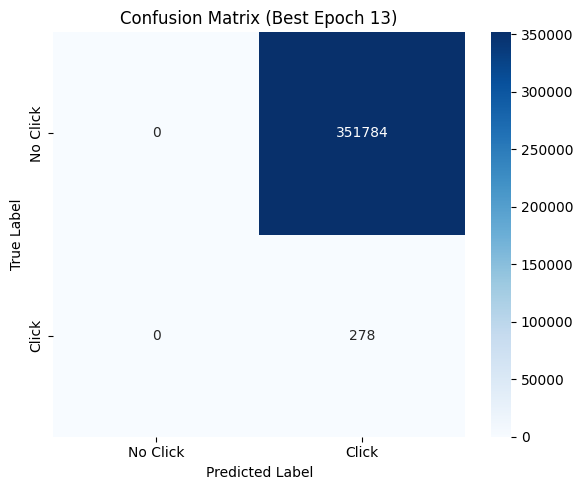

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 轉成 tensor
X_train_cat_tensor = torch.LongTensor(X_train[cat_embed_cols].values).to(device)
X_train_num_tensor = torch.FloatTensor(X_train[num_cols].values).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1).to(device)

X_valid_cat_tensor = torch.LongTensor(X_valid[cat_embed_cols].values).to(device)
X_valid_num_tensor = torch.FloatTensor(X_valid[num_cols].values).to(device)
y_valid_tensor = torch.FloatTensor(y_valid.values).view(-1, 1).to(device)

model = DNNWithEmbeddings(embedding_info, num_numerical=len(num_cols)).to(device)

# 計算正負類數量 → 給 BCEWithLogitsLoss 使用
num_pos = y_train.sum()
num_neg = len(y_train) - num_pos
pos_weight = torch.tensor([num_neg / num_pos]).to(device)
#pos_weight=torch.tensor([1000]).to(device)
# 使用加權 BCE loss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # 或使用 nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
best_auc = 0
best_metrics = {}

for epoch in range(20):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_cat_tensor, X_train_num_tensor)
    loss = criterion(y_pred, y_train_tensor)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        model.eval()
        y_train_pred = model(X_train_cat_tensor, X_train_num_tensor)
        y_valid_pred = model(X_valid_cat_tensor, X_valid_num_tensor)

        train_auc = roc_auc_score(y_train.values, y_train_pred.cpu().numpy())
        val_auc = roc_auc_score(y_valid.values, y_valid_pred.cpu().numpy())

        # Threshold = 0.5 判斷是否為 click
        y_valid_pred_label = (y_valid_pred.cpu().numpy() >= 0.5).astype(int)
        val_tpr = recall_score(y_valid.values, y_valid_pred_label)

        print(f"Epoch {epoch+1} | Loss: {loss.item():.4f} | Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f} | Val TPR: {val_tpr:.4f}")

        if val_auc > best_auc:
            best_auc = val_auc
            best_metrics = {
                "epoch": epoch + 1,
                "auc": val_auc,
                "tpr": val_tpr,
                "confusion": confusion_matrix(y_valid.values, y_valid_pred_label)
            }

# 最佳結果輸出
print("\n🏆 Best Epoch Results:")
print(f"Epoch: {best_metrics['epoch']}")
print(f"Best AUC: {best_metrics['auc']:.4f}")
print(f"Best TPR (Recall): {best_metrics['tpr']:.4f}")
#print("Confusion Matrix:\n", best_metrics["confusion"])
# 取得混淆矩陣
cm = best_metrics["confusion"]
labels = ["No Click", "Click"]
import seaborn as sns
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix (Best Epoch {best_metrics['epoch']})")
plt.tight_layout()
plt.show()